### 🤖 What are Multi-Agent RAG Systems?
A Multi-Agent RAG System splits the RAG pipeline into multiple specialized agents — each responsible for a specific role — and enables them to collaborate on a single query or task.

#### 1. 📋 Multi-Agent Network RAG System with LangGraph
Project Overview

A beginner-friendly Retrieval-Augmented Generation (RAG) system that uses a multi-agent architecture to intelligently answer questions from your documents. Built with LangGraph v0.3 for workflow orchestration and OpenAI for language understanding.

What It Does

Transforms your documents (PDFs, text files) into a searchable knowledge base that can answer questions intelligently using AI. Simply upload documents and ask questions in natural language - the system finds relevant information and generates comprehensive answers.
Key Features

- 📚 Multi-Format Support: Handles PDF and text documents
- 🤖 3-Agent Architecture: Specialized agents for document processing, retrieval, and answer generation
- 🔍 Smart Search: Vector-based semantic search finds relevant information
- 💬 Natural Language Q&A: Ask questions in plain English


In [2]:
import os
from dotenv import load_dotenv
load_dotenv()
from langchain.chat_models import init_chat_model
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")

c:\Users\Parth\Downloads\Agentic_Rag\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
llm=init_chat_model("openai:gpt-4o-mini")
llm

ChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x00000213713DCEC0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x00000213714B9370>, root_client=<openai.OpenAI object at 0x0000021370CCF680>, root_async_client=<openai.AsyncOpenAI object at 0x00000213710E4CB0>, model_name='gpt-4o-mini', model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

In [4]:
!pip install -U langchain-tavily

In [5]:
# --- Imports ---
import os
from typing import List
from dotenv import load_dotenv
from langchain_tavily import TavilySearch
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from langgraph.graph import StateGraph, END
from pydantic import BaseModel
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.tools import tool
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langgraph_supervisor import create_supervisor

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [6]:
# -----------------------------------------------
# 1. Document Preprocessing — Improved
# -----------------------------------------------

URLS = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2024-04-12-diffusion-video/",
    "https://lilianweng.github.io/posts/2025-05-01-thinking/",
    "https://lilianweng.github.io/posts/2024-11-28-reward-hacking/",
    "https://lilianweng.github.io/posts/2024-07-07-hallucination/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2024-02-05-human-data-quality/",
    "https://lilianweng.github.io/posts/2023-01-27-the-transformer-family-v2/",
    "https://lilianweng.github.io/posts/2023-01-10-inference-optimization/",
    "https://lilianweng.github.io/posts/2020-04-07-the-transformer-family/",
    "https://lilianweng.github.io/posts/2018-06-24-attention/",
    "https://lilianweng.github.io/posts/2019-01-31-lm/",
    "https://lilianweng.github.io/posts/2021-07-11-diffusion-models/",
    "https://lilianweng.github.io/posts/2018-08-12-vae/",
    "https://lilianweng.github.io/posts/2017-08-20-gan/",
    "https://lilianweng.github.io/posts/2018-10-13-flow-models/",
    "https://lilianweng.github.io/posts/2018-04-08-policy-gradient/",
    "https://lilianweng.github.io/posts/2018-02-19-rl-overview/",
    "https://lilianweng.github.io/posts/2021-03-21-lm-toxicity/",
    "https://lilianweng.github.io/posts/2021-01-02-controllable-text-generation/",
    "https://lilianweng.github.io/posts/2020-06-07-exploration-drl/",
    "https://lilianweng.github.io/posts/2021-05-31-contrastive/",
    "https://lilianweng.github.io/posts/2019-11-10-self-supervised/",
    "https://lilianweng.github.io/posts/2018-11-30-meta-learning/",
    "https://lilianweng.github.io/posts/2022-04-15-data-gen/",
    "https://lilianweng.github.io/posts/2022-02-20-active-learning/",
]

# -----------------------------------------------
# STEP 1: Load — Extract only the article body
# -----------------------------------------------
# FIX: Lilian Weng's blog has NO special CSS class on the article body.
# The content lives inside <article> or the main <div> under the <main> tag.
# SoupStrainer("article") correctly targets just the post content,
# skipping nav bars, footers, TOC, and sidebar menus entirely.

from langchain_community.document_loaders import WebBaseLoader
import bs4

def load_url(url: str):
    """Load a single URL, extracting only the article body."""
    loader = WebBaseLoader(
        web_paths=[url],
        bs_kwargs={
            "parse_only": bs4.SoupStrainer("article")  # ✅ matches actual HTML structure
        },
        requests_kwargs={
            "headers": {
                # Avoid being blocked by acting like a real browser
                "User-Agent": "Mozilla/5.0 (compatible; RAG-pipeline/1.0)"
            },
            "timeout": 15
        }
    )
    docs = loader.load()

    # Attach clean metadata to each doc for traceability in the vector store
    for doc in docs:
        doc.metadata["source_url"] = url
        doc.metadata["domain"] = "lilianweng.github.io"
        # Extract post title from URL slug (e.g. "2023-06-23-agent" → "agent")
        slug = url.rstrip("/").split("/")[-1]
        doc.metadata["post_slug"] = slug

    return docs

# Load all URLs with basic error handling so one bad URL doesn't crash everything
raw_docs = []
failed_urls = []

for url in URLS:
    try:
        docs = load_url(url)
        if docs and docs[0].page_content.strip():
            raw_docs.extend(docs)
            print(f"✅ Loaded: {url} ({len(docs[0].page_content)} chars)")
        else:
            # If article tag returned nothing, fall back to full page load
            print(f"⚠️  Empty article tag, retrying without filter: {url}")
            loader = WebBaseLoader(web_paths=[url])
            docs = loader.load()
            raw_docs.extend(docs)
    except Exception as e:
        print(f"❌ Failed: {url} — {e}")
        failed_urls.append(url)

print(f"\nLoaded {len(raw_docs)} docs | Failed: {len(failed_urls)}")

# -----------------------------------------------
# STEP 2: Clean — Strip noise before splitting
# -----------------------------------------------
# Remove table of contents, citation blocks, and reference sections
# BEFORE splitting so they don't pollute any chunks at all.

import re

def clean_text(text: str) -> str:
    # Remove markdown-style citation links like [1], [Wei et al. 2022]
    text = re.sub(r'\[\d+\]', '', text)
    # Remove lines that are purely a URL
    text = re.sub(r'^https?://\S+$', '', text, flags=re.MULTILINE)
    # Remove Table of Contents section entirely
    text = re.sub(r'Table of Contents.*?(?=\n#)', '', text, flags=re.DOTALL)
    # Remove References/Citation section at end of post
    text = re.sub(r'\n#+\s*(References|Citation|Bibliography).*$', '', text, flags=re.DOTALL)
    # Collapse 3+ blank lines into 2 (keeps paragraph structure intact)
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()

for doc in raw_docs:
    doc.page_content = clean_text(doc.page_content)

# -----------------------------------------------
# STEP 3: Split — Chunk with better sizing
# -----------------------------------------------
# FIX: chunk_size=800 is too small for technical posts with dense math/code.
# Increased to 1200 to keep explanations and their context in the same chunk.
# chunk_overlap=200 (was 100) ensures key sentences at boundaries aren't lost.
# add_start_index=True keeps char offset metadata for debugging retrieval issues.

from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    separators=[
        "\n## ",    # split at H2 headings first — natural section breaks
        "\n### ",   # then H3 subheadings
        "\n\n",     # then paragraphs
        "\n",       # then lines
        " ",        # then words
        ""          # last resort: characters
    ],
    chunk_size=1200,      # ✅ increased from 800 — better for technical content
    chunk_overlap=200,    # ✅ increased from 100 — less context loss at boundaries
    length_function=len,
    add_start_index=True,
)

split_docs = splitter.split_documents(raw_docs)
print(f"Total chunks before filtering: {len(split_docs)}")

# -----------------------------------------------
# STEP 4: Filter — Remove low-value chunks
# -----------------------------------------------
# FIX: Original filter was too aggressive (e.g. removing chunks starting with "[")
# which would remove valid content like "[Figure 1] shows...".
# New filters are more targeted and precise.

def is_valid_chunk(doc) -> bool:
    text = doc.page_content.strip()

    # Too short to be useful
    if len(text) < 150:
        return False

    # Pure reference list (lines all start with numbers or brackets)
    lines = [l.strip() for l in text.splitlines() if l.strip()]
    if lines and sum(1 for l in lines if re.match(r'^\[?\d+\]?\.?\s', l)) / len(lines) > 0.6:
        return False

    # Navigation / menu-heavy chunks (lots of short lines = nav links)
    if len(lines) > 5 and (sum(len(l) for l in lines) / len(lines)) < 30:
        return False

    # Pure whitespace or separator lines
    if re.fullmatch(r'[\s\-\*\_\#]+', text):
        return False

    return True

split_docs = [doc for doc in split_docs if is_valid_chunk(doc)]
print(f"Total chunks after filtering: {len(split_docs)}")


✅ Loaded: https://lilianweng.github.io/posts/2023-06-23-agent/ (43548 chars)
✅ Loaded: https://lilianweng.github.io/posts/2024-04-12-diffusion-video/ (31223 chars)
✅ Loaded: https://lilianweng.github.io/posts/2025-05-01-thinking/ (56098 chars)
✅ Loaded: https://lilianweng.github.io/posts/2024-11-28-reward-hacking/ (51093 chars)
✅ Loaded: https://lilianweng.github.io/posts/2024-07-07-hallucination/ (42479 chars)
✅ Loaded: https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/ (49430 chars)
✅ Loaded: https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/ (29838 chars)
✅ Loaded: https://lilianweng.github.io/posts/2024-02-05-human-data-quality/ (29339 chars)
✅ Loaded: https://lilianweng.github.io/posts/2023-01-27-the-transformer-family-v2/ (69593 chars)
✅ Loaded: https://lilianweng.github.io/posts/2023-01-10-inference-optimization/ (44406 chars)
✅ Loaded: https://lilianweng.github.io/posts/2020-04-07-the-transformer-family/ (37298 chars)
✅ Loaded: https://lilianweng.githu

In [7]:
### Vector Store Setup with FAISS and MMR Retriever

FAISS_INDEX_PATH = "faiss_index"

embedding = OpenAIEmbeddings(
    model="text-embedding-3-small",  # cheaper + faster than ada-002, often better
    chunk_size=200,                  # batch size for embedding API calls — avoids rate limits
)

# Load from disk if it already exists, otherwise build and save.
# This avoids re-embedding on every run — critical for cost and speed.
if os.path.exists(FAISS_INDEX_PATH):
    vectorstore = FAISS.load_local(
        FAISS_INDEX_PATH,
        embeddings=embedding,
        allow_dangerous_deserialization=True,  # required by LangChain for local loads
    )
    print("Loaded FAISS index from disk.")
else:
    vectorstore = FAISS.from_documents(split_docs, embedding)
    vectorstore.save_local(FAISS_INDEX_PATH)
    print(f"Built and saved FAISS index ({len(split_docs)} chunks).")


Loaded FAISS index from disk.


In [8]:

test_results = vectorstore.similarity_search("What is generative models and how many types are there?", k=3)
for doc in test_results:
    print(doc.metadata.get("source"))
    print(doc.page_content[:200])
    print("---")

https://lilianweng.github.io/posts/2021-07-11-diffusion-models/
[Updated on 2021-09-19: Highly recommend this blog post on score-based generative modeling by Yang Song (author of several key papers in the references)].
[Updated on 2022-08-27: Added classifier-free
---
https://lilianweng.github.io/posts/2018-10-13-flow-models/
Generative adversarial networks: GAN provides a smart solution to model the data generation, an unsupervised learning problem, as a supervised one. The discriminator model learns to distinguish the re
---
https://lilianweng.github.io/posts/2018-10-13-flow-models/
Comparison of three categories of generative models.

Linear Algebra Basics Recap#
We should understand two key concepts before getting into the flow-based generative model: the Jacobian determinant a
---


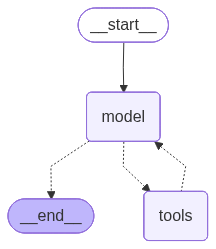

In [9]:
@tool("retrieve_docs")
def retrieve_docs(question: str) -> list:
    """Retrieve relevant docs, filtering out any below a similarity threshold."""
    # MMR search balances relevance and diversity:
    # fetch_k=20 pulls 20 candidate chunks, MMR then selects 10 that are
    # both relevant to the query and diverse from each other
    docs_with_scores = vectorstore.similarity_search_with_relevance_scores(
        question, k=10,
        search_type="mmr",
        search_kwargs={
            "fetch_k": 20,
            "lambda_mult": 0.6,  #### MMR parameters to balance relevance and diversity
        }
    )
    # Filter out chunks that are semantically too distant from the query.
    # Score range is 0-1; 0.3 threshold removes noise like citation blocks
    # and reference sections that MMR may still return despite low relevance.
    filtered_docs = [ 
        doc for doc, score in docs_with_scores if score >= 0.3
    ]
    return filtered_docs

tavily_tool = TavilySearch(
    max_results=10,                  # more sources = better academic coverage
    search_depth="advanced",         # deep crawl instead of surface-level snippets
    include_raw_content=True,        # returns full page content, not just summary
    include_answer=False,            # skip Tavily's summarized answer, get raw content instead
    include_domains=[                # restrict to high-quality academic sources
        "arxiv.org",
        "pubmed.ncbi.nlm.nih.gov",
        "scholar.google.com",
        "semanticscholar.org",
        "researchgate.net",
        "ncbi.nlm.nih.gov",
        "jstor.org",
        "springer.com",
        "ieee.org",
        "nature.com"
    ]
)

system_prompt =  """You are a researcher with access to retrieve_docs and web search tools.

        CORE SEARCH STRATEGY:
        Before searching, analyze the query and ask yourself:
        - How many distinct topics or concepts does this query contain?
        - Does this query ask for a comparison, a list, or multiple subtopics?
        
        If the query contains MULTIPLE distinct topics or comparisons:
        - Break it into separate focused sub-queries
        - Call retrieve_docs ONCE PER sub-query with a focused, specific query string
        - Never pass the entire original question as one search query if it 
          contains multiple distinct concepts
        
        If the query is SIMPLE and single-topic:
        - One retrieve_docs call is sufficient
        
        Examples of how to decompose:
        - "Compare memory in agents vs diffusion models" 
          → search 1: "memory systems LLM autonomous agents"
          → search 2: "information retention diffusion models video generation"
          
        - "Explain MIPS, reward hacking, and prompt engineering"
          → search 1: "MIPS approximate nearest neighbors vector retrieval"
          → search 2: "reward hacking reinforcement learning LLM"
          → search 3: "prompt engineering techniques LLM"
        
        - "What is short term memory in agents"
          → search 1: "short term memory LLM agents" (single search, simple query)

        After retrieving, synthesize ALL findings into a clear summary.
        Do NOT just return raw documents — summarize what you found.
        """


model = ChatOpenAI(
    model="gpt-5",
    temperature=0.1,
    max_tokens=1000,
    timeout=30
    # ... (other params)
)
research_agent = create_agent(model, 
                    tools=[retrieve_docs, tavily_tool],
                    name = "research_expert",
                    system_prompt=system_prompt)
research_agent

In [10]:
system_prompt_blog = """You are an expert technical blog writer specializing in AI and machine learning.

        YOUR ONLY JOB IS TO WRITE — you have no search tools and don't need them.
        All the research has already been done for you and is provided in the message history.

        Writing Standards:
        - Write in a clear, engaging technical style (think Lilian Weng's blog level)
        - Always structure posts with: Introduction, multiple H2 sections, Conclusion
        - Include concrete examples and analogies to explain complex concepts
        - Reference specific findings from the researcher's notes
        - Never fabricate facts — only use what the researcher provided

        When improving an existing draft:
        - Preserve what's already good
        - Fill in gaps using the NEW research findings provided
        - Make transitions between sections smooth

        When you are done, explicitly state what (if anything) is still missing.
        If the blog is complete and needs no more research, say COMPLETE at the end.
        """
blog_agent = create_agent(
    model=llm,
    tools=[],           # no tools — blog agent only writes, never searches
    name="blog_writer",
    system_prompt=system_prompt_blog
)

In [11]:
workflow = create_supervisor(
    agents=[research_agent, blog_agent],
    model=llm,
    prompt=(
        "You are a manager for a technical content team. "
        "1. Delegate to the 'research_expert' to gather data on the user's topic. "
        "2. Review the findings. If more details are needed, send them back to research. "
        "3. Once information is sufficient, delegate to 'blog_writer' to write the post. "
        "4. When the blog is complete, deliver the final result to the user."
    ),
    add_handoff_back_messages=True,  # allows agents to send messages back to each other for clarification or additional info
    output_mode="last_message" # Returns only the final blog post to the user
)

# Compile the final graph
app = workflow.compile()

# --- 4. Execution ---
query= """Write a comprehensive blog post covering the complete architecture 
of LLM-powered autonomous agents — including planning, memory systems, 
tool use, reflection mechanisms, and the challenges of hallucination 
and adversarial attacks. Compare how these components evolved from 
2021 transformer models to 2025 reasoning models."""

result = app.invoke({
    "messages": [HumanMessage(content=query)]
})

print(result["messages"][-1].content)

The blog post on the architecture of LLM-powered autonomous agents has been completed. It details their evolution from 2021 transformer models to advanced reasoning models anticipated in 2025, covering key components like planning, memory systems, tool usage, reflection mechanisms, and the challenges of hallucination and adversarial attacks.

If there are any specific adjustments or additional information you'd like to include, please let me know!


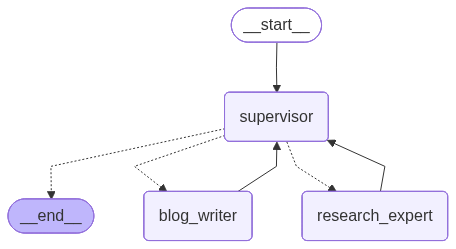

In [13]:
app

In [14]:
result["messages"]

[HumanMessage(content='Write a comprehensive blog post covering the complete architecture \nof LLM-powered autonomous agents — including planning, memory systems, \ntool use, reflection mechanisms, and the challenges of hallucination \nand adversarial attacks. Compare how these components evolved from \n2021 transformer models to 2025 reasoning models.', additional_kwargs={}, response_metadata={}, id='d90d1b25-c640-4216-b494-13d6ee276e1f'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 208, 'total_tokens': 222, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_373a14eb6f', 'id': 'chatcmpl-DCIiyr0Yea9OikspKa4McN7kDMj3l', 'service_tier': 'default', 'fin